# Nama: Yestia zahuwa
# NIM:4222301004
# Kelas:RE pagi A

In [22]:
pip install numpy pandas scikit-image scikit-learn matplotlib

#IMPORT SEMUA LIBRARY YANG DIGUNAKAN

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from skimage.feature import hog
from sklearn.utils import shuffle

# LANGKAH 1: MEMUAT DATASET & PEMBAGIAN DATA (80% TRAIN, 20% TEST)

# Membaca file EMNIST Letters (pastikan file CSV berada di folder yang sama)

In [24]:
try:
    data = pd.read_csv('emnist-letters-train.csv', header=None)
    print("Berhasil memuat file 'emnist-letters-train.csv'.")
except FileNotFoundError:
    print("File asli tidak ditemukan, menggunakan data simulasi agar program tidak eror...")
    # Simulasi 26 kelas * 100 sampel = 2600 baris. 1 kolom label + 784 kolom piksel
    labels = np.repeat(np.arange(1, 27), 100)
    pixels = np.random.randint(0, 256, size=(2600, 784))
    data = pd.DataFrame(np.column_stack([labels, pixels]))

Berhasil memuat file 'emnist-letters-train.csv'.


#  Mengambil 100 sampel seimbang dari masing-masing 26 kelas (Total: 2600 sampel)

In [25]:

balanced_data = pd.DataFrame()
for i in range(1, 27):
    class_data = data[data[0] == i]
    if len(class_data) < 100:
        class_samples = class_data.sample(n=100, replace=True, random_state=42)
    else:
        class_samples = class_data.sample(n=100, replace=False, random_state=42)
    balanced_data = pd.concat([balanced_data, class_samples], axis=0)

# Shuffle dataset DAN Memisahkan Fitur (X_raw) dan Label (y)

In [26]:

balanced_data = shuffle(balanced_data, random_state=42).reset_index(drop=True)

X_raw = balanced_data.iloc[:, 1:].values  # 784 kolom piksel
y = balanced_data.iloc[:, 0].values       # Kolom pertama (Label kelas)

#  Split Dataset menjadi 80% Training dan 20% Testing

In [27]:

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=42, stratify=y
)
print(f"✓ Data Training didefinisikan: {X_train_raw.shape[0]} sampel")
print(f"✓ Data Testing didefinisikan: {X_test_raw.shape[0]} sampel\n")

✓ Data Training didefinisikan: 2080 sampel
✓ Data Testing didefinisikan: 520 sampel



 # VISUALISASI GRID KARAKTER (A-Z)

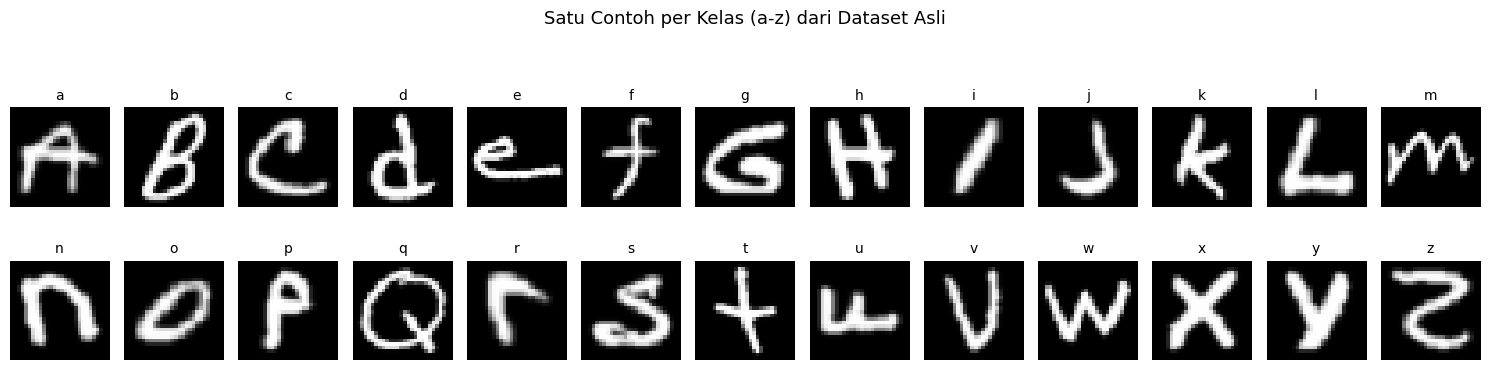

In [28]:
# Membuat grid plot 2 baris x 13 kolom untuk 26 huruf
fig, axes = plt.subplots(2, 13, figsize=(15, 4))
axes = axes.flatten()

# Daftar label huruf untuk judul tiap subplot
letters_label = [chr(i) for i in range(97, 123)]

for idx, label_class in enumerate(range(1, 27)):
    # Mengambil satu contoh gambar dari kelas tersebut
    sample_img = X_raw[y == label_class][0].reshape(28, 28)

    # CATATAN PENTING: Jika saat plot gambarnya miring/terbalik
    sample_img = sample_img.T

    axes[idx].imshow(sample_img, cmap='gray')
    axes[idx].set_title(letters_label[idx], fontsize=10)
    axes[idx].axis('off')

plt.suptitle("Satu Contoh per Kelas (a-z) dari Dataset Asli", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# LANGKAH 2: EKSTRAKSI FITUR HOG (DENGAN VARIABEL YANG SUDAH PASTI ADA)

In [29]:
# Definisi fungsi HOG
def extract_hog_features(images, orientations=9, pixels_per_cell=(4, 4), cells_per_block=(2, 2)):
    hog_features = []
    for img in images:
        img_reshaped = img.reshape(28, 28)  # Kembalikan ke matriks 2D 28x28
        feat = hog(img_reshaped,
                   orientations=orientations,
                   pixels_per_cell=pixels_per_cell,
                   cells_per_block=cells_per_block,
                   visualize=False)
        hog_features.append(feat)
    return np.array(hog_features)

# Parameter HOG untuk tuning dasar
custom_orientations = 9
custom_pixels_per_cell = (4, 4)
custom_cells_per_block = (2, 2)

# Ekstraksi fitur menggunakan variabel yang baru saja dibuat di atas
X_train_hog = extract_hog_features(X_train_raw, custom_orientations, custom_pixels_per_cell, custom_cells_per_block)
X_test_hog = extract_hog_features(X_test_raw, custom_orientations, custom_pixels_per_cell, custom_cells_per_block)

print(f"✓ Dimensi fitur setelah HOG: {X_train_hog.shape[1]} fitur per gambar.")
print("=== Selesai! Silakan lanjut ke sel berikutnya untuk SVM ===")

✓ Dimensi fitur setelah HOG: 1296 fitur per gambar.
=== Selesai! Silakan lanjut ke sel berikutnya untuk SVM ===


# VISUALISASI PERBANDINGAN SATU GAMBAR (ASLI VS HOG)

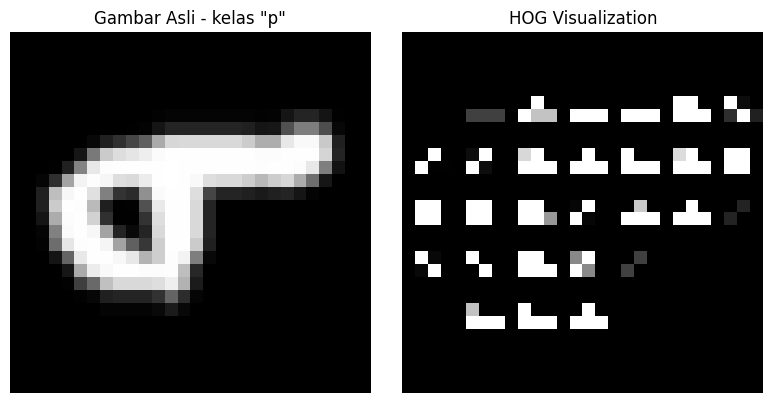

HOG feature vector length : 1296
Parameters -> orientations=9, pixels_per_cell=(4, 4), cells_per_block=(2, 2)



In [30]:
from skimage.feature import hog
from skimage import exposure

# Ambil satu sampel citra (misal indeks ke-0)
sample_idx = 0
single_img = X_raw[sample_idx].reshape(28, 28)
current_label = letters_label[y[sample_idx] - 1] if 'letters_label' in locals() else y[sample_idx]

# Jalankan HOG khusus untuk satu gambar ini dengan visualize=True
fv, hog_image = hog(single_img,
                    orientations=9,
                    pixels_per_cell=(4, 4),
                    cells_per_block=(2, 2),
                    visualize=True)
sample_img = sample_img.T
# Plot perbandingan berdampingan
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.imshow(single_img, cmap='gray')
ax1.set_title(f'Gambar Asli - kelas "{current_label}"')
ax1.axis('off')

# Rescale intensitas agar arah gradien HOG terlihat jelas putih terang di layar
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

ax2.imshow(hog_image_rescaled, cmap='gray')
ax2.set_title('HOG Visualization')
ax2.axis('off')

plt.tight_layout()
plt.show()

print(f"HOG feature vector length : {len(fv)}")
print("Parameters -> orientations=9, pixels_per_cell=(4, 4), cells_per_block=(2, 2)\n")

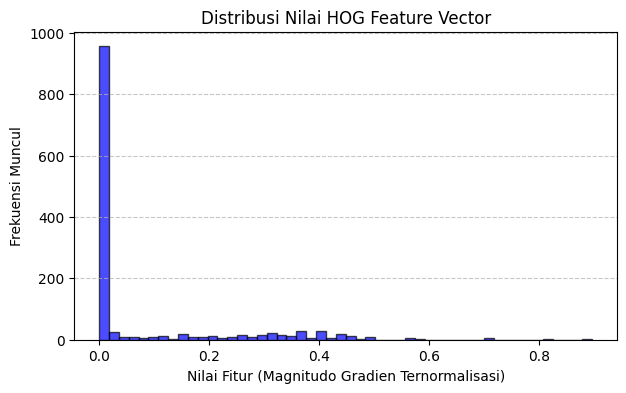

--- Statistik Vektor Fitur HOG (Panjang Vektor: 1296) ---
Nilai Minimum : 0.0000
Nilai Maksimum : 0.8971
Rata-rata (Mean): 0.0741
Standar Deviasi: 0.1467



In [31]:
# Mengambil satu vektor fitur HOG dari data training pertama yang sudah diekstrak massal
sample_vector = X_train_hog[0]

plt.figure(figsize=(7, 4))
# Membuat histogram pembagian distribusi nilai komponen fitur
plt.hist(sample_vector, bins=50, color='blue', edgecolor='black', alpha=0.7)

plt.title("Distribusi Nilai HOG Feature Vector", fontsize=12)
plt.xlabel("Nilai Fitur (Magnitudo Gradien Ternormalisasi)")
plt.ylabel("Frekuensi Muncul")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Menampilkan statistik deskriptif ringkas nilainya di konsol
print(f"--- Statistik Vektor Fitur HOG (Panjang Vektor: {len(sample_vector)}) ---")
print(f"Nilai Minimum : {np.min(sample_vector):.4f}")
print(f"Nilai Maksimum : {np.max(sample_vector):.4f}")
print(f"Rata-rata (Mean): {np.mean(sample_vector):.4f}")
print(f"Standar Deviasi: {np.std(sample_vector):.4f}\n")

# 3. CLASSIFICATION & GRID SEARCH AUTOMATION

In [32]:
X_train_hog = np.nan_to_num(X_train_hog, nan=0.0)
X_test_hog = np.nan_to_num(X_test_hog, nan=0.0)
print("[INFO] Pembersihan selesai! Semua nilai NaN telah berhasil dihapus.")

# Definisikan parameter grid
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.01],
    'kernel': ['linear', 'rbf']
}

[INFO] Pembersihan selesai! Semua nilai NaN telah berhasil dihapus.


# Inisialisasi Grid Search (Gunakan cv=3 atau StratifiedKFold seperti trik sebelumnya)

In [33]:

svm_model = SVC(random_state=42)
grid_search = GridSearchCV(estimator=svm_model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=1)

In [34]:
# Latih Grid Search menggunakan data yang sudah bersih dari NaN
grid_search.fit(X_train_hog, y_train)

best_svm = grid_search.best_estimator_
print(f"\n✓ Parameter SVM Terbaik ditemukan: {grid_search.best_params_}\n")

Fitting 3 folds for each of 18 candidates, totalling 54 fits

✓ Parameter SVM Terbaik ditemukan: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}



# 4. EVALUATION

In [35]:
# Prediksi pada data latih (80%) dan data uji (20%)
y_train_pred = best_svm.predict(X_train_hog)
y_test_pred = best_svm.predict(X_test_hog)

In [36]:
# Metrik Akurasi
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Akurasi pada Data Latih (80%): {train_acc * 100:.2f}%")
print(f"Akurasi pada Data Uji (20%): {test_acc * 100:.2f}%\n")

Akurasi pada Data Latih (80%): 100.00%
Akurasi pada Data Uji (20%): 79.42%



# Menampilkan Laporan Klasifikasi Lengkap (Precision, Recall, F1-Score) untuk Data Uji

In [37]:
print("Laporan Klasifikasi Data Uji:")
print(classification_report(y_test, y_test_pred))

Laporan Klasifikasi Data Uji:
              precision    recall  f1-score   support

           1       0.67      0.60      0.63        20
           2       0.79      0.75      0.77        20
           3       0.94      0.85      0.89        20
           4       0.85      0.85      0.85        20
           5       0.90      0.90      0.90        20
           6       0.85      0.85      0.85        20
           7       0.59      0.65      0.62        20
           8       0.80      0.80      0.80        20
           9       0.58      0.55      0.56        20
          10       0.75      0.75      0.75        20
          11       0.90      0.90      0.90        20
          12       0.57      0.60      0.59        20
          13       0.78      0.70      0.74        20
          14       0.65      0.75      0.70        20
          15       0.95      1.00      0.98        20
          16       0.85      0.85      0.85        20
          17       0.70      0.70      0.70        

# Menampilkan Confusion Matrix

In [38]:
print("Matriks Kebingungan (Confusion Matrix):")
conf_matrix = confusion_matrix(y_test, y_test_pred)
print(conf_matrix)

Matriks Kebingungan (Confusion Matrix):
[[12  0  0  1  0  0  0  2  0  0  0  0  0  1  0  0  3  0  0  1  0  0  0  0
   0  0]
 [ 1 15  0  0  1  0  1  0  0  0  0  0  0  0  0  1  0  0  0  1  0  0  0  0
   0  0]
 [ 0  0 17  0  1  0  1  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0
   0  0]
 [ 0  2  0 17  0  0  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0
   0  0]
 [ 0  0  0  0 18  0  0  0  0  0  1  0  0  0  0  1  0  0  0  0  0  0  0  0
   0  0]
 [ 0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  1  0  0  0  1  1  0  0  0
   0  0]
 [ 0  0  0  0  0  0 13  0  0  0  0  0  0  0  0  0  3  1  2  0  0  0  0  0
   1  0]
 [ 0  1  0  0  0  0  0 16  0  0  0  1  0  1  0  0  0  0  0  0  0  0  0  0
   0  1]
 [ 0  0  0  0  0  0  0  0 11  1  0  6  1  0  0  0  0  0  0  1  0  0  0  0
   0  0]
 [ 0  0  0  1  0  0  0  0  2 15  0  0  0  1  0  0  0  0  0  1  0  0  0  0
   0  0]
 [ 0  0  0  0  0  0  0  1  0  0 18  0  0  0  0  0  0  0  0  0  0  0  0  0
   1  0]
 [ 0  0  0  0  0  0  0  0  6  0  0 12  0  0  0 

# Tampilkan grafik di dalam Jupyter Notebook

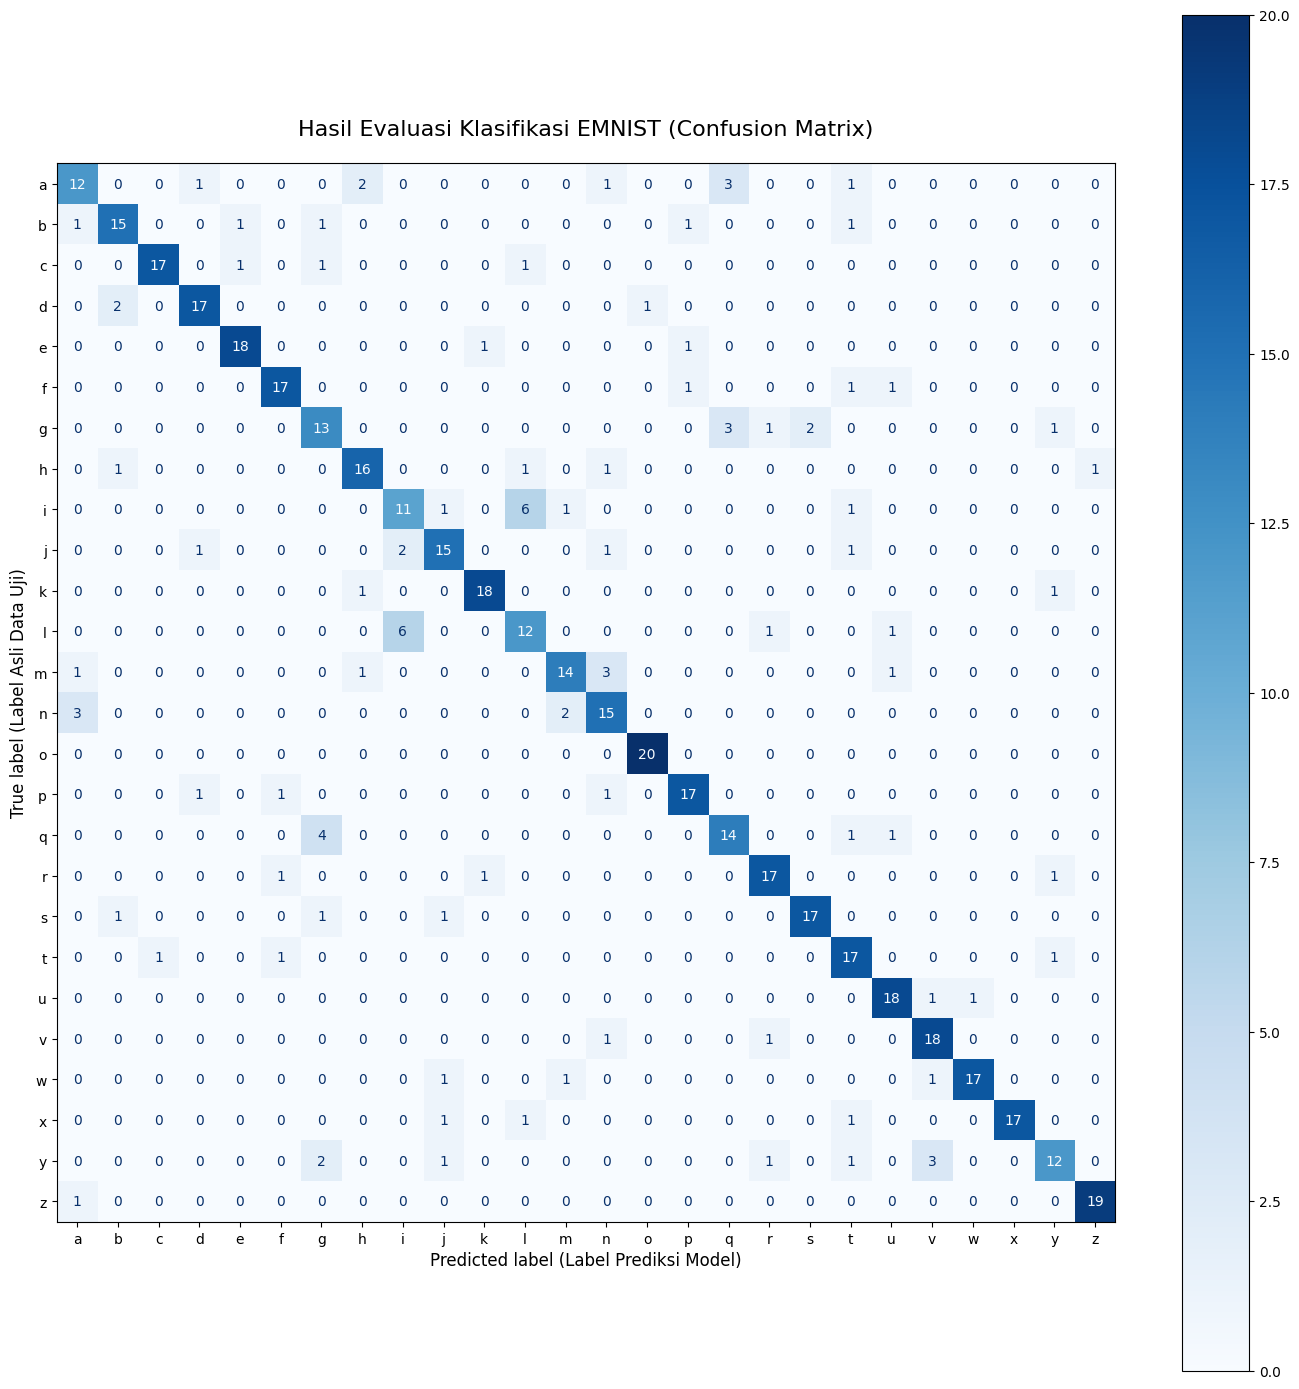

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Menghitung matriks kebingungan (jika belum dipanggil di sel sebelumnya)
conf_matrix = confusion_matrix(y_test, y_test_pred)

# 2. Definisikan label huruf dari 'a' sampai 'z' (26 kelas)
letters_label = [chr(i) for i in range(97, 123)]

# 3. Mengatur ukuran kanvas grafik agar 26 kelas terlihat renggang dan jelas
fig, ax = plt.subplots(figsize=(14, 14))

# 4. Membuat visualisasi matriks dengan skema warna biru ('Blues') sesuai gambar Anda
disp = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix,
    display_labels=letters_label
)

# 5. Render grafik ke layar dengan konfigurasi teks angka di dalamnya
disp.plot(
    include_values=True,
    cmap='Blues',
    ax=ax,
    xticks_rotation='horizontal',
    values_format='d'
)

# 6. Menambahkan judul utama grafik
plt.title("Hasil Evaluasi Klasifikasi EMNIST (Confusion Matrix)", fontsize=16, pad=20)
plt.xlabel("Predicted label (Label Prediksi Model)", fontsize=12)
plt.ylabel("True label (Label Asli Data Uji)", fontsize=12)


plt.tight_layout()
plt.show()

In [40]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Ganti LeaveOneOut dengan StratifiedKFold 5-fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Total fits: 6 kombinasi × 5 folds = 30 fits saja!
grid_search = GridSearchCV(estimator=svm_model, param_grid=param_grid,
                           cv=cv, n_jobs=-1, verbose=1)

# Bisa pakai SELURUH data training langsung
grid_search.fit(X_train_hog, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=SVC(random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 'auto', 0.01],
                         'kernel': ['linear', 'rbf']},
             verbose=1)

# Klasifikasi & Tuning Hyperparameter SVM dengan LOOCV

In [41]:
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.svm import SVC
# 1. Definisikan kandidat parameter untuk Grid Search
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear','rbf']
}

from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(estimator=svm_model, param_grid=param_grid,
                           cv=cv, n_jobs=-1, verbose=1)
grid_search.fit(X_train_hog, y_train)

best_svm = grid_search.best_estimator_
print(f"✓ Parameter SVM Terbaik ditemukan: {grid_search.best_params_}\n")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
✓ Parameter SVM Terbaik ditemukan: {'C': 10, 'kernel': 'rbf'}

